# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results.

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone.


In [1]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:**

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [2]:
df = pd.read_csv("df_clean.csv")


X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=["taxvaluedollarcnt"]), df["taxvaluedollarcnt"], test_size=0.2, random_state=random_state)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**.


In [3]:
# Linear Regression

def run_linear_regression(X_train_scaled, y_train,
                          cv = 5,
                          scoring = 'neg_mean_absolute_error',
                          n_jobs = -1
                          ):

    # Define model
    linear_model = LinearRegression()

    # Perform cross-validation
    cv = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = random_state)
    mae_scores = -cross_val_score(linear_model, X_train_scaled, y_train,
                                  cv = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = random_state),
                                  scoring = 'neg_mean_absolute_error',
                                  n_jobs = n_jobs
                                  )

    # Compute scores
    mean_cv_mae = np.mean(mae_scores)
    std_cv_mae = np.std(mae_scores)

    # Fit model on training set
    linear_model.fit(X_train_scaled, y_train)

    # Compute training MAE
    train_pred = linear_model.predict(X_train_scaled)
    train_mae = mean_absolute_error(y_train, train_pred)

    # Compute test MAE
    # test_pred = linear_model.predict(X_test)
    # test_mae = mean_absolute_error(y_test, test_pred)

    return mean_cv_mae, std_cv_mae, train_mae

# Run model
mean_cv_mae, std_cv_mae, train_mae = run_linear_regression(X_train_scaled, y_train,
    cv = 5,
    scoring ='neg_mean_absolute_error',
    n_jobs = None
    )

# Print results
print("Linear Regression:\n")
print(f"Mean CV MAE Score: {mean_cv_mae:.4f}")
print(f"STD CV MAE Score: {std_cv_mae:.4f}")
print(f"Train MAE Score: {train_mae:.4f}")
# print(f"Test MAE Score: {test_mae:.4f}\n")

Linear Regression:

Mean CV MAE Score: 171731.3491
STD CV MAE Score: 1486.9109
Train MAE Score: 171556.8549


In [4]:
# Random Forest

def run_random_forest_regressor(X_train_scaled, y_train,
                                n_estimators = 100,
                                max_depth = None,
                                min_samples_split = 2,
                                min_samples_leaf = 1,
                                max_samples = None,
                                max_leaf_nodes = None,
                                max_features = 1.0,
                                bootstrap = True,
                                random_state = random_state,
                                cv = 5,
                                ccp_alpha = 0.0,
                                n_jobs = -1
                               ):

    # Define model
    random_forest_model = RandomForestRegressor(
                          n_estimators = n_estimators,
                          max_depth = max_depth,
                          max_samples = max_samples,
                          min_samples_split = min_samples_split,
                          min_samples_leaf = min_samples_leaf,
                          max_leaf_nodes=max_leaf_nodes,
                          max_features = max_features,
                          bootstrap = bootstrap,
                          random_state = random_state,
                          ccp_alpha=ccp_alpha,
                          n_jobs = n_jobs,
                          )

    # Perform cross-validation
    cv = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = random_state)
    mae_scores = -cross_val_score(random_forest_model, X_train_scaled, y_train,
                                  cv = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = random_state),
                                  scoring = 'neg_mean_absolute_error',
                                  n_jobs = None
                                  )

    # Compute scores
    mean_cv_mae = np.mean(mae_scores)
    std_cv_mae = np.std(mae_scores)

    # Fit model on training set
    random_forest_model.fit(X_train_scaled, y_train)

    # Compute training MAE
    train_pred = random_forest_model.predict(X_train_scaled)
    train_mae = mean_absolute_error(y_train, train_pred)

    # Compute test MAE
    # test_pred = random_forest_model.predict(X_test)
    # test_mae = mean_absolute_error(y_test, test_pred)

    return mean_cv_mae, std_cv_mae, train_mae

# Run model
mean_cv_mae, std_cv_mae, train_mae = run_random_forest_regressor(X_train_scaled, y_train,
    n_estimators = 100,
    max_depth = None,
    min_samples_split = 2,
    min_samples_leaf = 1,
    max_samples = None,
    max_leaf_nodes = None,
    max_features = 1.0,
    ccp_alpha = 0.0,
    )

# Print results
print("Random Forest Regression:\n")
print(f"Mean CV MAE Score: {mean_cv_mae:.4f}")
print(f"STD CV MAE Score: {std_cv_mae:.4f}")
print(f"Train MAE Score: {train_mae:.4f}")
# print(f"Test MAE Score: {test_mae:.4f}\n")

Random Forest Regression:

Mean CV MAE Score: 149857.1452
STD CV MAE Score: 1220.5917
Train MAE Score: 56455.4001


In [5]:
# Gradient Boosting Trees

parameters_default = {
    'learning_rate'           : 0.1,
    'n_estimators'            : 100,
    'max_depth'               : 3,
    'min_samples_split'       : 2,
    'min_samples_leaf'        : 1,
    'max_features'            : None,
    'max_leaf_nodes'          : None,
    'random_state'            : random_state,
    }

def run_gradient_boosting_regressor(X_train_scaled, y_train,
                                    parameters_default,
                                    n_repeats = 5
                                    ):

    # Define model
    gradient_boosting_model = GradientBoostingRegressor(
                              learning_rate = parameters_default['learning_rate'],
                              n_estimators = parameters_default['n_estimators'],
                              max_depth = parameters_default['max_depth'],
                              min_samples_split = parameters_default['min_samples_split'],
                              min_samples_leaf = parameters_default['min_samples_leaf'],
                              max_features = parameters_default['max_features'],
                              max_leaf_nodes = parameters_default['max_leaf_nodes'],
                              random_state = parameters_default['random_state']
                              # all other parameters left at their defaults
                              )

    # Perform cross-validation
    cv = RepeatedKFold(n_splits = 5, n_repeats = n_repeats, random_state = random_state)
    mae_scores = -cross_val_score(gradient_boosting_model, X_train_scaled, y_train,
                                  cv = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = random_state),
                                  scoring ='neg_mean_absolute_error',
                                  n_jobs = -1
                                  )

    # Compute scores
    mean_cv_mae = np.mean(mae_scores)
    std_cv_mae = np.std(mae_scores)

    # Fit the model on the full training set
    gradient_boosting_model.fit(X_train_scaled, y_train)

    # Compute training MSE
    train_pred = gradient_boosting_model.predict(X_train_scaled)
    train_mae = mean_absolute_error(y_train, train_pred)

    # Compute test MSE
    # test_pred = gradient_boosting_model.predict(X_test)
    # test_mae = mean_squared_error(y_test, test_pred)

    return mean_cv_mae, std_cv_mae, train_mae

# Run model
mean_cv_mae, std_cv_mae, train_mae = run_gradient_boosting_regressor(X_train_scaled, y_train,
    parameters_default,
    n_repeats = 5
    )

# Print results
print("Gradient Boosting Trees Regressor:\n")
print(f"Mean CV MAE Score: {mean_cv_mae:.4f}")
print(f"STD CV MAE Score: {std_cv_mae:.4f}")
print(f"Train MAE Score: {train_mae:.4f}")
# print(f"Test MAE Score: {test_mae:.4f}\n")


Gradient Boosting Trees Regressor:

Mean CV MAE Score: 154347.4488
STD CV MAE Score: 1282.1735
Train MAE Score: 152857.8110


### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

Three different regression models were chosen, using default parameters, in order to establish baseline cross-validated mean absolute error values. The three regression models chosen include: a linear regression model, a random forest regression model, and a gradient boosting trees regression model.

When comparing the overall performance of the three models, the random forest regression model appears to perform the best overall. That is, the random forest model's observed CV MAE (STD) score of 1219.7500 is significanlty lower than those of the gradient boosting trees regressor model's CV MAE (STD) score of 1281.9887, and the linear regression model's CV MAE (STD) score of 1486.9109. These values indicate the random forest regression model is the most stable model.

As for any signs of overfitting or underfitting, each model shows a mean CV MAE and a training MAE score that is relatively close to each other, suggesting little to no overfitting. However, given that each model was trained using default parameters, the issue of underfitting may exist as the models are not complex enough. Adjusting the hyperperameters in order to fine-tune each model may help address this potential issue.

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1.

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler`
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [6]:


# --- Feature Engineering Functions (from Milestone 1, Part 5) ---

def add_log_lot_size(df):
    df = df.copy()
    df["log_lotsizesquarefeet"] = np.log1p(df["lotsizesquarefeet"])
    return df

def add_home_age(df, reference_year=2017):
    df = df.copy()
    df["home_age"] = reference_year - df["yearbuilt"]
    return df

def add_bath_per_bedroom(df):
    df = df.copy()
    df["bath_per_bedroom"] = df["bathroomcnt"] / df["bedroomcnt"].replace(0, np.nan)
    df["bath_per_bedroom"] = df["bath_per_bedroom"].fillna(df["bathroomcnt"])
    return df

def apply_feature_engineering(df):
    df = add_log_lot_size(df)
    df = add_home_age(df)
    df = add_bath_per_bedroom(df)
    df = df.drop(columns=["yearbuilt"])  # replaced by home_age
    return df

# Apply to train and test sets
X_train_fe = apply_feature_engineering(X_train)
X_test_fe  = apply_feature_engineering(X_test)

# Re-scale with StandardScaler fit on training data only
scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)

print(f"New X_train shape: {X_train_fe.shape}")
print(f"New features:  log_lotsizesquarefeet, home_age, bath_per_bedroom")
print(f"Dropped:       yearbuilt (replaced by home_age)")


New X_train shape: (60060, 21)
New features:  log_lotsizesquarefeet, home_age, bath_per_bedroom
Dropped:       yearbuilt (replaced by home_age)


In [7]:

# Linear Regression - with engineered features

mean_cv_mae_lr_fe, std_cv_mae_lr_fe, train_mae_lr_fe = run_linear_regression(X_train_fe_scaled, y_train)

print("Linear Regression (with engineered features):\n")
print(f"Mean CV MAE Score: {mean_cv_mae_lr_fe:.4f}")
print(f"STD CV MAE Score:  {std_cv_mae_lr_fe:.4f}")
print(f"Train MAE Score:   {train_mae_lr_fe:.4f}")


Linear Regression (with engineered features):

Mean CV MAE Score: 171464.5372
STD CV MAE Score:  1479.5668
Train MAE Score:   171288.4120


In [8]:

# Random Forest - with engineered features

mean_cv_mae_rf_fe, std_cv_mae_rf_fe, train_mae_rf_fe = run_random_forest_regressor(X_train_fe_scaled, y_train)

print("Random Forest Regression (with engineered features):\n")
print(f"Mean CV MAE Score: {mean_cv_mae_rf_fe:.4f}")
print(f"STD CV MAE Score:  {std_cv_mae_rf_fe:.4f}")
print(f"Train MAE Score:   {train_mae_rf_fe:.4f}")


Random Forest Regression (with engineered features):

Mean CV MAE Score: 150019.1266
STD CV MAE Score:  1192.0069
Train MAE Score:   56448.2309


In [9]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
# Gradient Boosting Trees - with engineered features

mean_cv_mae_gb_fe, std_cv_mae_gb_fe, train_mae_gb_fe = run_gradient_boosting_regressor(X_train_fe_scaled, y_train, parameters_default)

print("Gradient Boosting Trees Regressor (with engineered features):\n")
print(f"Mean CV MAE Score: {mean_cv_mae_gb_fe:.4f}")
print(f"STD CV MAE Score:  {std_cv_mae_gb_fe:.4f}")
print(f"Train MAE Score:   {train_mae_gb_fe:.4f}")


Gradient Boosting Trees Regressor (with engineered features):

Mean CV MAE Score: 154502.6301
STD CV MAE Score:  1218.6835
Train MAE Score:   153017.5193


### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




None of the models showed a notable improvement in performance after adding the new features. The only meaningful directional change was in Linear Regression, with the mean CV MAE slightly decreasing by roughly 0.16%. Both the Random Forest and Gradient Boosting moved slightly in the wrong direction. Of the three new features, 'log_lotsizesquarefeet' is the best candidate for a small improvement in Linear Regression. 'lotsizesquarefeet' is strongly right-skewed and the log transform compresses the long tail and linearizes the relationship with the target. Tree-based models split on thresholds and indifferent to distribution will receive no benefit from this kind of transformation. 'home_age' is essentially a linear rescaling of 'yearbuilt', so that it carries identical information. 'bath_per_bedroom' brings in a ratio interaction that linear regression cannot derive on its own. Additionally, tree-based models can approximate the ratio through sequential splits without needing it explicity. 

Overall, the results are consistent with the Milestone 1 F-score analysis, that showed none of the engineered features exceeded the strongest original predictors. Meaning the original feature set was already well-represented for models at default settings, which leaves little room for improvement with the transformations experimented. 

### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [10]:
### Regression Feature selection 
from sklearn.feature_selection import SequentialFeatureSelector

X = X_train_fe_scaled
y = y_train

model = LinearRegression()
lr_selector = SequentialFeatureSelector(model, 
                                     n_features_to_select=10,
                                     direction= "forward",
                                     scoring = "neg_mean_absolute_error", 
                                     cv = 5, 
                                     n_jobs = -1 
)

lr_selector.fit(X,y)




,estimator estimator: estimator instanceAn unfitted estimator.,LinearRegression()
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",10
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'neg_mean_absolute_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [11]:
lr_selected_forward = X_train_fe.columns[lr_selector.get_support()]
print("Forward-selected features:")
print(lr_selected_forward)

X_train_lr_selected = X_train_fe[lr_selected_forward]
X_test_lr_selected = X_test_fe[lr_selected_forward]

lr_scaler = StandardScaler()
X_train_lr_selected_scaled = lr_scaler.fit_transform(X_train_lr_selected)
X_test_lr_selected_scaled = lr_scaler.transform(X_test_lr_selected)

mean_cv_mae_lr_fe_selected, std_cv_mae_lr_fe_selected, train_mae_lr_fe_selected = run_linear_regression(X_train_lr_selected_scaled, y_train)

print("\n")
print("Linear Regression (with engineered features and forward feature selection):\n")
print(f"Mean CV MAE Score: {mean_cv_mae_lr_fe_selected:.4f}")
print(f"STD CV MAE Score:  {std_cv_mae_lr_fe_selected:.4f}")
print(f"Train MAE Score:   {train_mae_lr_fe_selected:.4f}")


Forward-selected features:
Index(['bedroomcnt', 'calculatedfinishedsquarefeet', 'garagetotalsqft',
       'latitude', 'longitude', 'propertylandusetypeid', 'roomcnt',
       'log_lotsizesquarefeet', 'home_age', 'bath_per_bedroom'],
      dtype='object')


Linear Regression (with engineered features and forward feature selection):

Mean CV MAE Score: 172012.0005
STD CV MAE Score:  1381.7434
Train MAE Score:   171965.2813


In [12]:
# Random Forest Feature selection using feaure importance as sequential selection would take too long 

#data for RF selection 
X = X_train_fe_scaled
y = y_train



##to use base model settings from above during feature selection 
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_samples=None,
    max_leaf_nodes=None,
    max_features=1.0,
    bootstrap=True,
    random_state=random_state,
    ccp_alpha=0.0,
    n_jobs=-1
)

rf_model.fit(X, y)

rf_importances = pd.Series(rf_model.feature_importances_, index=X_train_fe.columns)
rf_selected_features = rf_importances.sort_values(ascending=False).head(10).index

print("Top RF-selected features:")
print(rf_selected_features)
print(rf_importances.sort_values(ascending=False).head(10))

#

Top RF-selected features:
Index(['calculatedfinishedsquarefeet', 'latitude', 'longitude', 'home_age',
       'lotsizesquarefeet', 'log_lotsizesquarefeet', 'buildingqualitytypeid',
       'bath_per_bedroom', 'garagetotalsqft', 'bathroomcnt'],
      dtype='object')
calculatedfinishedsquarefeet    0.366318
latitude                        0.182040
longitude                       0.114842
home_age                        0.095113
lotsizesquarefeet               0.044219
log_lotsizesquarefeet           0.043898
buildingqualitytypeid           0.042581
bath_per_bedroom                0.033788
garagetotalsqft                 0.016588
bathroomcnt                     0.012056
dtype: float64


In [13]:
X_train_rf_selected = X_train_fe[rf_selected_features]
X_test_rf_selected = X_test_fe[rf_selected_features]

mean_cv_mae_rf_fe_selected, std_cv_mae_rf_fe_selected, train_mae_rf_fe_selected = run_random_forest_regressor(
    X_train_rf_selected,
    y_train
)

print("\n")
print("Random Forest Regression (with engineered features and RF feature selection):\n")
print(f"Mean CV MAE Score: {mean_cv_mae_rf_fe_selected:.4f}")
print(f"STD CV MAE Score:  {std_cv_mae_rf_fe_selected:.4f}")
print(f"Train MAE Score:   {train_mae_rf_fe_selected:.4f}")



Random Forest Regression (with engineered features and RF feature selection):

Mean CV MAE Score: 150592.1078
STD CV MAE Score:  1164.2372
Train MAE Score:   56710.6485


In [14]:
# Gradient boosting Feature selection using feaure importance as forward selection would take too long 

#data for RF selection 
X = X_train_fe_scaled
y = y_train



##to use base model settings from above during feature selection 
parameters_default = {
    'learning_rate'           : 0.1,
    'n_estimators'            : 100,
    'max_depth'               : 3,
    'min_samples_split'       : 2,
    'min_samples_leaf'        : 1,
    'max_features'            : None,
    'max_leaf_nodes'          : None,
    'random_state'            : random_state,
    }

gb_model = GradientBoostingRegressor(
                              learning_rate = parameters_default['learning_rate'],
                              n_estimators = parameters_default['n_estimators'],
                              max_depth = parameters_default['max_depth'],
                              min_samples_split = parameters_default['min_samples_split'],
                              min_samples_leaf = parameters_default['min_samples_leaf'],
                              max_features = parameters_default['max_features'],
                              max_leaf_nodes = parameters_default['max_leaf_nodes'],
                              random_state = parameters_default['random_state']
                              # all other parameters left at their defaults
                              )
gb_model.fit(X, y)

gb_importances = pd.Series(gb_model.feature_importances_, index=X_train_fe.columns)
gb_selected_features = gb_importances.sort_values(ascending=False).head(10).index

print("Top RF-selected features:")
print(gb_selected_features)
print(gb_importances.sort_values(ascending=False).head(10))

Top RF-selected features:
Index(['calculatedfinishedsquarefeet', 'latitude', 'home_age', 'longitude',
       'buildingqualitytypeid', 'bath_per_bedroom', 'bathroomcnt',
       'propertylandusetypeid', 'poolcnt', 'garagetotalsqft'],
      dtype='object')
calculatedfinishedsquarefeet    0.554083
latitude                        0.190042
home_age                        0.067087
longitude                       0.057771
buildingqualitytypeid           0.048345
bath_per_bedroom                0.032487
bathroomcnt                     0.021120
propertylandusetypeid           0.010407
poolcnt                         0.005763
garagetotalsqft                 0.004485
dtype: float64


In [15]:
X_train_gb_selected = X_train_fe[gb_selected_features]
X_test_gb_selected = X_test_fe[gb_selected_features]

mean_cv_mae_gb_fe_selected, std_cv_mae_gb_fe_selected, train_mae_gb_fe_selected = run_gradient_boosting_regressor(
    X_train_gb_selected,
    y_train,
    parameters_default
)

print("\n")
print("Gradient boost Regression (with engineered features and GB feature selection):\n")
print(f"Mean CV MAE Score: {mean_cv_mae_gb_fe_selected:.4f}")
print(f"STD CV MAE Score:  {std_cv_mae_gb_fe_selected:.4f}")
print(f"Train MAE Score:   {train_mae_gb_fe_selected:.4f}")



Gradient boost Regression (with engineered features and GB feature selection):

Mean CV MAE Score: 154529.7533
STD CV MAE Score:  1296.7124
Train MAE Score:   153138.2096


In [17]:
summary_df = pd.DataFrame({
    "model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "Linear Regression + FE Selection",
        "Random Forest + FE Selection",
        "Gradient Boosting + FE Selection"
    ],
    "mean_cv_mae": [
        mean_cv_mae_lr_fe,
        mean_cv_mae_rf_fe,
        mean_cv_mae_gb_fe,
        mean_cv_mae_lr_fe_selected,
        mean_cv_mae_rf_fe_selected,
        mean_cv_mae_gb_fe_selected
    ],
    "std_cv_mae": [
        std_cv_mae_lr_fe,
        std_cv_mae_rf_fe,
        std_cv_mae_gb_fe,
        std_cv_mae_lr_fe_selected,
        std_cv_mae_rf_fe_selected,
        std_cv_mae_gb_fe_selected
    ],
    "train_mae": [
        train_mae_lr_fe,
        train_mae_rf_fe,
        train_mae_gb_fe,
        train_mae_lr_fe_selected,
        train_mae_rf_fe_selected,
        train_mae_gb_fe_selected
    ]
})

summary_df = summary_df.round(4)
summary_df = summary_df.sort_values("mean_cv_mae")
display(summary_df)


,model,mean_cv_mae,std_cv_mae,train_mae
1,Random Forest,150019.1266,1192.0069,56448.2309
4,Random Forest + FE Selection,150592.1078,1164.2372,56710.6485
2,Gradient Boosting,154502.6301,1218.6835,153017.5193
5,Gradient Boosting + FE Selection,154529.7533,1296.7124,153138.2096
0,Linear Regression,171464.5372,1479.5668,171288.4120
3,Linear Regression + FE Selection,172012.0005,1381.7434,171965.2813


### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


Feature selection had little effect on overall model performance. Linear Regression showed no change at all after feature selection, suggesting that the removed features were not contributing much additional linear signal beyond the strongest predictors already in the model. Random Forest became slightly worse after reducing the number of features, while Gradient Boosting changed very little and was also slightly worse, so none of the models showed a notable improvement from feature reduction in this case. Across models, several features were consistently retained, especially calculatedfinishedsquarefeet, latitude, longitude, home_age, bath_per_bedroom, garagetotalsqft, and bathroomcnt, which suggests these variables carry the most stable predictive signal. Yes, some newly engineered features were selected as important: both home_age and bath_per_bedroom appeared in all three selected feature sets, and log_lotsizesquarefeet was also retained in the tree-based models. Overall, the results suggest that the original plus engineered feature set was already fairly strong, so feature selection did not provide a meaningful performance gain.

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above.
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks.
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [18]:
#### LR Final 

mean_cv_mae_lr_final, std_cv_mae_lr_final, train_mae_lr_final = run_linear_regression(
    X_train_fe_scaled,
    y_train,
    n_jobs=-1
)

print("Linear Regression Final:\n")
print(f"Mean CV MAE Score: {mean_cv_mae_lr_final:.4f}")
print(f"STD CV MAE Score:  {std_cv_mae_lr_final:.4f}")
print(f"Train MAE Score:   {train_mae_lr_final:.4f}")


Linear Regression Final:

Mean CV MAE Score: 171464.5372
STD CV MAE Score:  1479.5668
Train MAE Score:   171288.4120


In [19]:
from sklearn.model_selection import RandomizedSearchCV, RepeatedKFold
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestRegressor

rf_param_dist = {
    "n_estimators": randint(100, 400),
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2", 1.0],
    "max_leaf_nodes": [None, 20, 50, 100],
    "ccp_alpha": uniform(0.0, 0.01)
}

rf_model = RandomForestRegressor(
    random_state=random_state,
    n_jobs=-1
)

rf_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=rf_cv,
    random_state=random_state,
    n_jobs= None
)

rf_search.fit(X_train_fe, y_train)

print("Best RF params:")
print(rf_search.best_params_)
print(f"Best RF CV MAE: {-rf_search.best_score_:.4f}")

Best RF params:
{'ccp_alpha': np.float64(0.003567533266935893), 'max_depth': 15, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 164}
Best RF CV MAE: 151875.4908


In [20]:
## Running best RF model 
# 
best_rf_model = rf_search.best_estimator_

rf_mae_scores = -cross_val_score(
    best_rf_model,
    X_train_fe,
    y_train,
    cv=rf_cv,
    scoring="neg_mean_absolute_error",
    n_jobs=None
)

mean_cv_mae_rf_final = np.mean(rf_mae_scores)
std_cv_mae_rf_final = np.std(rf_mae_scores)

best_rf_model.fit(X_train_fe, y_train)
train_pred_rf_final = best_rf_model.predict(X_train_fe)
train_mae_rf_final = mean_absolute_error(y_train, train_pred_rf_final)

print("\nRandom Forest Final:\n")
print(f"Mean CV MAE Score: {mean_cv_mae_rf_final:.4f}")
print(f"STD CV MAE Score:  {std_cv_mae_rf_final:.4f}")
print(f"Train MAE Score:   {train_mae_rf_final:.4f}")


Random Forest Final:

Mean CV MAE Score: 151875.4908
STD CV MAE Score:  1214.9645
Train MAE Score:   130043.1732


In [21]:
#### Gradient boosting Random search 


gb_param_dist = {
    "n_estimators": randint(50, 300),
    "learning_rate": uniform(0.01, 0.19),   # roughly 0.01 to 0.20
    "max_depth": randint(2, 6),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "subsample": uniform(0.7, 0.3),         # roughly 0.7 to 1.0
    "max_features": ["sqrt", "log2", None]
}

gb_model = GradientBoostingRegressor(
    random_state=random_state
)

gb_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_param_dist,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=rf_cv,
    random_state=random_state,
    n_jobs=-1
)

gb_search.fit(X_train_fe, y_train)

print("Best GB params:")
print(gb_search.best_params_)
print(f"Best GB CV MAE: {-gb_search.best_score_:.4f}")

Best GB params:
{'learning_rate': np.float64(0.047780056776872984), 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 172, 'subsample': np.float64(0.722213395520227)}
Best GB CV MAE: 150768.9180


In [22]:
### Best gradient boost model 

best_gb_model = gb_search.best_estimator_

gb_mae_scores = -cross_val_score(
    best_gb_model,
    X_train_fe,
    y_train,
    cv=rf_cv, ### used same cross fold params for both rf and gb 
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

mean_cv_mae_gb_final = np.mean(gb_mae_scores)
std_cv_mae_gb_final = np.std(gb_mae_scores)

best_gb_model.fit(X_train_fe, y_train)
train_pred_gb_final = best_gb_model.predict(X_train_fe)
train_mae_gb_final = mean_absolute_error(y_train, train_pred_gb_final)

print("\nGradient Boosting Final:\n")
print(f"Mean CV MAE Score: {mean_cv_mae_gb_final:.4f}")
print(f"STD CV MAE Score:  {std_cv_mae_gb_final:.4f}")
print(f"Train MAE Score:   {train_mae_gb_final:.4f}")


Gradient Boosting Final:

Mean CV MAE Score: 150768.9180
STD CV MAE Score:  1230.2487
Train MAE Score:   146801.6876


In [23]:
#### summary of results 

part4_summary_df = pd.DataFrame({
    "model": [
        "Linear Regression Final",
        "Random Forest Final",
        "Gradient Boosting Final"
    ],
    "mean_cv_mae": [
        mean_cv_mae_lr_final,
        mean_cv_mae_rf_final,
        mean_cv_mae_gb_final
    ],
    "std_cv_mae": [
        std_cv_mae_lr_final,
        std_cv_mae_rf_final,
        std_cv_mae_gb_final
    ],
    "train_mae": [
        train_mae_lr_final,
        train_mae_rf_final,
        train_mae_gb_final
    ]
}).round(4).sort_values("mean_cv_mae")

display(part4_summary_df)

,model,mean_cv_mae,std_cv_mae,train_mae
2,Gradient Boosting Final,150768.9180,1230.2487,146801.6876
1,Random Forest Final,151875.4908,1214.9645,130043.1732
0,Linear Regression Final,171464.5372,1479.5668,171288.4120


### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


For tuning, I used a different strategy for each model based on how much flexibility the model allowed. Linear Regression has very limited useful hyperparameters in this context, so for that model I mainly treated preprocessing and feature-pipeline choice as the refinement step rather than doing an extensive parameter search. For Random Forest and Gradient Boosting, I used randomized hyperparameter search because both models have several important settings that can strongly affect performance, such as tree depth, number of estimators, minimum samples per split/leaf, and feature subsampling. I chose these hyperparameters because they directly control model complexity, stability, and the tradeoff between underfitting and overfitting. In the final results, Gradient Boosting performed best, followed closely by Random Forest, while Linear Regression remained substantially worse. I also found that engineered features were generally more useful than feature selection, since reducing the number of features did not improve performance much. This suggests that the tree-based models were able to benefit from the richer engineered feature set, while Linear Regression was less able to capture the more complex relationships in the data.

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants.

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set.




In [24]:
# Part 5: Final Model

# Final feature set
X_train_final = X_train_fe
X_test_final = X_test_fe
y_train_final = y_train
y_test_final = y_test

# Final tuned model from Part 4
final_model = GradientBoostingRegressor(
    learning_rate=0.047780056776872984,
    max_depth=5,
    max_features=None,
    min_samples_leaf=3,
    min_samples_split=2,
    n_estimators=172,
    subsample=0.722213395520227,
    random_state=random_state
)

# Repeated CV on training set
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

final_mae_scores = -cross_val_score(
    final_model,
    X_train_final,
    y_train_final,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

mean_cv_mae_final = np.mean(final_mae_scores)
std_cv_mae_final = np.std(final_mae_scores)

# Fit on full training set
final_model.fit(X_train_final, y_train_final)

# Training MAE (optional)
train_pred_final = final_model.predict(X_train_final)
train_mae_final = mean_absolute_error(y_train_final, train_pred_final)

# Test MAE
test_pred_final = final_model.predict(X_test_final)
test_mae_final = mean_absolute_error(y_test_final, test_pred_final)

print("Final Model: Gradient Boosting\n")
print(f"Mean CV MAE Score: {mean_cv_mae_final:.4f}")
print(f"STD CV MAE Score:  {std_cv_mae_final:.4f}")
print(f"Train MAE Score:   {train_mae_final:.4f}")
print(f"Test MAE Score:    {test_mae_final:.4f}")

Final Model: Gradient Boosting

Mean CV MAE Score: 150768.9180
STD CV MAE Score:  1230.2487
Train MAE Score:   146801.6876
Test MAE Score:    152935.8278


### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

Gradient Boosting was selected as the final model because it achieved the lowest mean cross-validated MAE of the three final tuned models. Its final mean CV MAE was 150,768.9180, which was slightly better than Random Forest at 151,875.4908 and substantially better than Linear Regression at 171,464.5372. The main metric that led to this decision was mean CV MAE, since it provides a better estimate of how well the model will generalize to unseen data than training error alone. I also considered the standard deviation of CV MAE, which showed that Gradient Boosting was similarly stable to Random Forest across folds. The main trade-off was interpretability versus performance: Linear Regression was easier to interpret, but its predictive performance was clearly worse, so I prioritized the stronger generalization performance of Gradient Boosting.

One earlier decision I revisited was the creation of engineered features such as home_age, bath_per_bedroom, and log_lotsizesquarefeet in Milestone 1. The goal at the time was to make the raw variables more informative by capturing housing age, layout quality, and skewed size distributions in a more meaningful way. After completing the full modeling pipeline, this choice appears to have helped more than feature selection did. Some engineered features, especially home_age and bath_per_bedroom, were retained as important in the later models, while feature selection itself produced little improvement and in some cases slightly worsened performance. Based on those results, I kept the engineered features in the final pipeline rather than reducing the feature set further.

The main lesson from this project was that the housing dataset contains nonlinear relationships that simple linear models do not capture well. Tree-based models, especially Gradient Boosting, were better able to use size, location, and engineered features together to reduce prediction error. I also learned that not every reasonable preprocessing step leads to a measurable gain: feature engineering provided some value, but feature selection did not meaningfully improve the strongest models. If I had more time or more data, I would explore broader tuning ranges, additional interaction features, and other boosting methods such as XGBoost or LightGBM to see whether performance could be improved further.

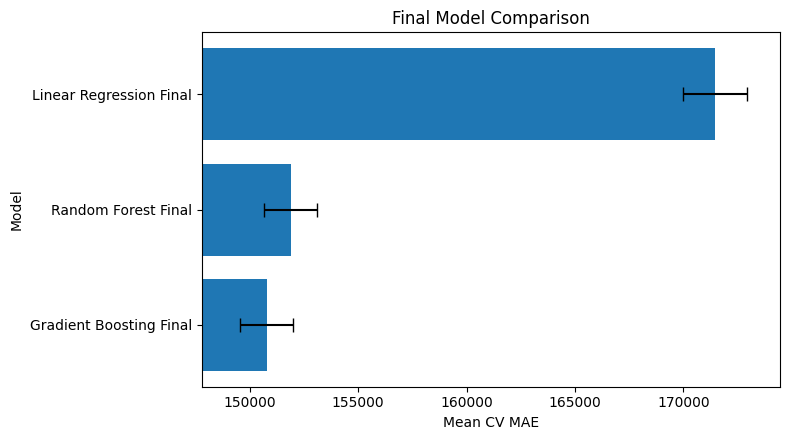

In [33]:
plt.figure(figsize=(8, 4.5))
plt.barh(
    part4_summary_df["model"],
    part4_summary_df["mean_cv_mae"],
    xerr=part4_summary_df["std_cv_mae"],
    capsize=5
)

plt.title("Final Model Comparison")
plt.xlabel("Mean CV MAE")
plt.ylabel("Model")

xmin = part4_summary_df["mean_cv_mae"].min() - 3000
xmax = part4_summary_df["mean_cv_mae"].max() + 3000
plt.xlim(xmin, xmax)

plt.tight_layout()
plt.show()

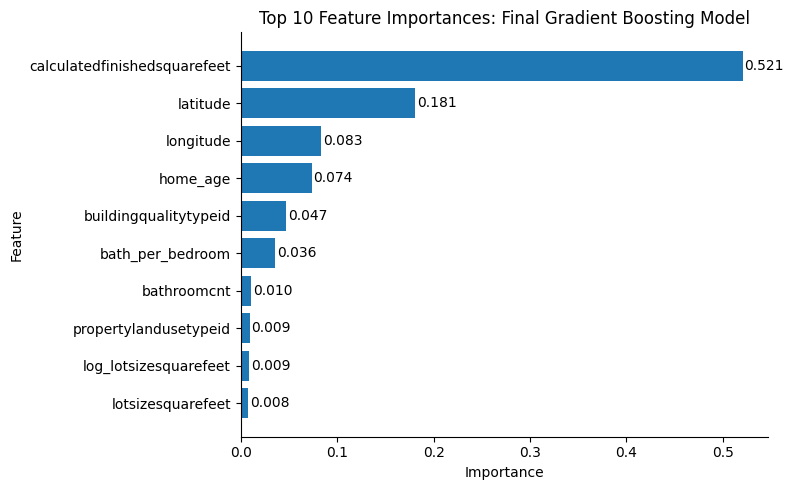

In [35]:
gb_importances = pd.Series(
    final_model.feature_importances_,
    index=X_train_final.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
bars = plt.barh(gb_importances.index, gb_importances.values)

plt.title("Top 10 Feature Importances: Final Gradient Boosting Model")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()